In [35]:
%pip install numpy pandas mne tensorflow scikit-learn torch

Note: you may need to restart the kernel to use updated packages.


In [52]:
import os
import mne
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cosine
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader 

mne.set_log_level('WARNING')

In [ ]:
class Config:
    # Update this path to your local dataset folder
    DATASET_PATH = os.environ.get("EEG_DATASET_PATH", "./data/files")
    RUN_ID = 1
    TARGET_CHANNELS = ['Oz', 'T7', 'Cz']
    WINDOW_SIZE = 160
    STRIDE = 4
    SAMPLE_RATE = 160
    TRAIN_SUBJECTS = range(1, 90)
    TEST_SUBJECTS = range(90, 109)
    BATCH_SIZE = 64
    EPOCHS = 30

In [48]:
#Data Preprocessing Part
def gram_schmidt(vectors):
    """
    Orthogonalizes channels to remove correlation (Paper Method).
    Args:
        vectors (np.array): Shape (n_samples, n_channels)
    Returns:
        np.array: Orthogonalized vectors
    """
    basis = np.zeros_like(vectors)
    for i in range(vectors.shape[1]):
        v = vectors[:, i]
        u = v.copy()
        for j in range(i):
            prev_u = basis[:, j]
            norm_prev = np.dot(prev_u, prev_u)
            if norm_prev > 1e-10:
                projection = (np.dot(v, prev_u) / norm_prev) * prev_u
                u -= projection
        basis[:, i] = u
    return basis

def create_segments(data, label, window_size, stride):
    """Slice continuous signal into training segments."""
    n_samples = data.shape[0]
    segments = []
    labels = []
    for start in range(0, n_samples - window_size + 1, stride):
        end = start + window_size
        segment = data[start:end, :]
        if segment.shape == (window_size, data.shape[1]):
            segments.append(segment)
            labels.append(int(label))
    return segments, labels

def load_data_for_subjects(subject_list, config):
    """Loads, orthogonalizes, and segments data for a list of subjects."""
    all_X = []
    all_y = []
    
    print(f"Loading data for {len(subject_list)} subjects...")
    
    for i, subject_id in enumerate(subject_list):
        try:
            # Construct file path
            path = f"{config.DATASET_PATH}/S{subject_id:03d}/S{subject_id:03d}R{config.RUN_ID:02d}.edf"
            if not os.path.exists(path):
                continue
                
            # Load & Resample
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
            if raw.info['sfreq'] != config.SAMPLE_RATE:
                raw.resample(config.SAMPLE_RATE, npad="auto", verbose=False)
            
            mne.rename_channels(raw.info, lambda x: x.strip('.'))
            try:
                raw.pick(config.TARGET_CHANNELS)
            except ValueError:
                continue
                
            data = raw.get_data().T
            
            # Apply Gram-Schmidt & Scaling
            data = gram_schmidt(data)
            scaler = MinMaxScaler(feature_range=(0, 1))
            data = scaler.fit_transform(data)
            
            # Create Segments
            X, y = create_segments(data, i, config.WINDOW_SIZE, config.STRIDE)
            
            all_X.extend(X)
            all_y.extend(y)
            
        except Exception as e:
            print(f"  Error S{subject_id}: {e}")
            
    return np.array(all_X), np.array(all_y)

In [39]:
# Build the Siamesse Network
def build_embedding_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Reshape(
        (input_shape[0], input_shape[1], 1)
    )(inputs)

    # block 1
    x = tf.keras.layers.Conv2D(32, (5, 2), activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.BatchNormalization()(x)


    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 2), activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # block 3
    x = tf.keras.layers.Conv2D(128, (3, 2), activation="relu", padding="same")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)


    # the fingerprint Layer
    outputs = tf.keras.layers.Dense(
        128, activation="relu", name="fingerprint_layer"
    )(x)

    return tf.keras.Model(inputs, outputs, name="EmbeddingNetwork")

In [40]:
def triplet_loss(margin=0.3):
    def loss(y_true, y_pred):
        a, p, n = tf.split(y_pred, 3, axis=1)

        a = tf.math.l2_normalize(a, axis=1)
        p = tf.math.l2_normalize(p, axis=1)
        n = tf.math.l2_normalize(n, axis=1)

        d_ap = 1 - tf.reduce_sum(a * p, axis=1)
        d_an = 1 - tf.reduce_sum(a * n, axis=1)

        return tf.reduce_mean(tf.maximum(d_ap - d_an + margin, 0.0))
    return loss

In [41]:
def build_triplet_model(input_shape):
    embedding = build_embedding_model(input_shape)

    anchor   = tf.keras.Input(shape=input_shape, name="anchor")
    positive = tf.keras.Input(shape=input_shape, name="positive")
    negative = tf.keras.Input(shape=input_shape, name="negative")

    emb_a = embedding(anchor)
    emb_p = embedding(positive)
    emb_n = embedding(negative)

    output = tf.keras.layers.Concatenate(axis=1)([emb_a, emb_p, emb_n])

    return tf.keras.Model([anchor, positive, negative], output)

In [49]:
# LOADING THE DATA
cfg = Config()
print("Phase 1: Loading Training Data (Subject 1 - 89) ... ")
X_train, y_train = load_data_for_subjects(cfg.TRAIN_SUBJECTS, cfg)

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)

idx = np.arange(len(X_train))
np.random.shuffle(idx)
X_train, y_train = X_train[idx], y_train[idx]

Phase 1: Loading Training Data (Subject 1 - 89) ... 
Loading data for 89 subjects...


In [50]:
# Make a genrator
def make_triplets(X, y):
    A, P, N = [], [], []

    classes = np.unique(y)
    idxs = {c: np.where(y == c)[0] for c in classes}

    for i in range(len(X)):
        anchor = X[i]
        label = int(y[i])

        pos_idx = np.random.choice(idxs[label])
        neg_label = np.random.choice(classes[classes != label])
        neg_idx = np.random.choice(idxs[neg_label])

        A.append(anchor)
        P.append(X[pos_idx])
        N.append(X[neg_idx])

    return np.array(A), np.array(P), np.array(N)


In [54]:
# Training part
A, P, N = make_triplets(X_train, y_train)

triplet_model = build_triplet_model((cfg.WINDOW_SIZE, 3))

triplet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=triplet_loss(margin=0.3)
)

print("Training Triplet Network...")
triplet_model.fit(
    [A, P, N],
    np.zeros(len(A)),   # dummy labels
    epochs=cfg.EPOCHS,
    batch_size=cfg.BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Training Triplet Network...
Epoch 1/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 341s 113ms/step - loss: 0.0567 - val_loss: 0.0180
Epoch 2/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 336s 112ms/step - loss: 0.0153 - val_loss: 0.0170
Epoch 3/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 325s 108ms/step - loss: 0.0100 - val_loss: 0.0100
Epoch 4/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 333s 111ms/step - loss: 0.0071 - val_loss: 0.0128
Epoch 5/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 333s 111ms/step - loss: 0.0056 - val_loss: 0.0059
Epoch 6/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 335s 112ms/step - loss: 0.0044 - val_loss: 0.0052
Epoch 7/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 336s 112ms/step - loss: 0.0037 - val_loss: 0.0051
Epoch 8/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 336s 112ms/step - loss: 0.0032 - val_loss: 0.0048
Epoch 9/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 334s 111ms/step - loss: 0.0027 - val_loss: 0.0037
Epoch 10/10
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 328s 109ms/step - loss: 0.0023 - val_loss: 0.0038


In [59]:
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)


X_train shape: (213569, 160, 3)
y_train shape: (213569,)


In [56]:
fingerprint_model = triplet_model.get_layer("EmbeddingNetwork")

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy.spatial.distance import cosine
import numpy as np

def evaluate_authentication(model, X_test, y_test):
    """
    Evaluate open-set EEG biometric authentication using triplet embeddings.
    - Safe cosine distance
    - L2-normalized embeddings
    - ROC curve + EER calculation
    - Histogram of genuine vs impostor distances
    """
    
    def safe_cosine(u, v, eps=1e-8):
        norm_u = np.linalg.norm(u)
        norm_v = np.linalg.norm(v)
        if norm_u < eps or norm_v < eps:
            return 1.0
        return 1 - np.dot(u, v) / (norm_u * norm_v)
    
    print(f"Generating embeddings for {len(X_test)} test samples...")
    embeddings = model.predict(X_test, batch_size=128, verbose=1)
    
    # L2-normalize embeddings
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / np.maximum(norms, 1e-8)

    unique_users = np.unique(y_test)
    all_gen_scores, all_imp_scores = [], []

    for user_idx in unique_users:
        user_indices = np.where(y_test == user_idx)[0]
        impostor_indices = np.where(y_test != user_idx)[0]
        
        if len(user_indices) < 2:
            continue
        
        # Split 50% enrollment, 50% probe
        split_point = len(user_indices) // 2
        enroll_indices = user_indices[:split_point]
        probe_indices = user_indices[split_point:]
        
        template = embeddings[enroll_indices].mean(axis=0)
        
        # Genuine scores
        for vec in embeddings[probe_indices]:
            all_gen_scores.append(safe_cosine(template, vec))
        
        # Impostor scores (sample up to 100)
        np.random.shuffle(impostor_indices)
        sel_imp_indices = impostor_indices[:100]
        for vec in embeddings[sel_imp_indices]:
            all_imp_scores.append(safe_cosine(template, vec))

    # Convert to similarity for ROC
    y_true = [1]*len(all_gen_scores) + [0]*len(all_imp_scores)
    y_scores = (1 - np.array(all_gen_scores)).tolist() + (1 - np.array(all_imp_scores)).tolist()
    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Equal Error Rate (EER)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    EER = fpr[eer_idx]
    optimal_threshold = thresholds[eer_idx]
    
    print(f"\n=== RESULTS ===")
    print(f"AUC: {roc_auc:.4f}")
    print(f"EER: {EER:.4f} ({EER*100:.2f}%)")
    print(f"Optimal Similarity Threshold: {optimal_threshold:.4f}")
    
    # ROC plot
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.2f})', color='darkorange', lw=2)
    plt.plot([0,1], [0,1], linestyle='--', color='navy')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('EEG Triplet Authentication ROC')
    plt.legend(loc='lower right')
    plt.show()
    
    # Distance histogram
    plt.figure(figsize=(8,6))
    plt.hist(all_gen_scores, bins=50, alpha=0.6, label='Genuine')
    plt.hist(all_imp_scores, bins=50, alpha=0.6, label='Impostor')
    plt.xlabel('Cosine Distance')
    plt.ylabel('Frequency')
    plt.title('Genuine vs Impostor Distances')
    plt.legend()
    plt.show()
    
    return optimal_threshold


Loading data for 19 subjects...
Generating embeddings for 45619 test samples...
357/357 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step

=== RESULTS ===
AUC: 0.9771
EER: 0.0732 (7.32%)
Optimal Similarity Threshold: 0.6140


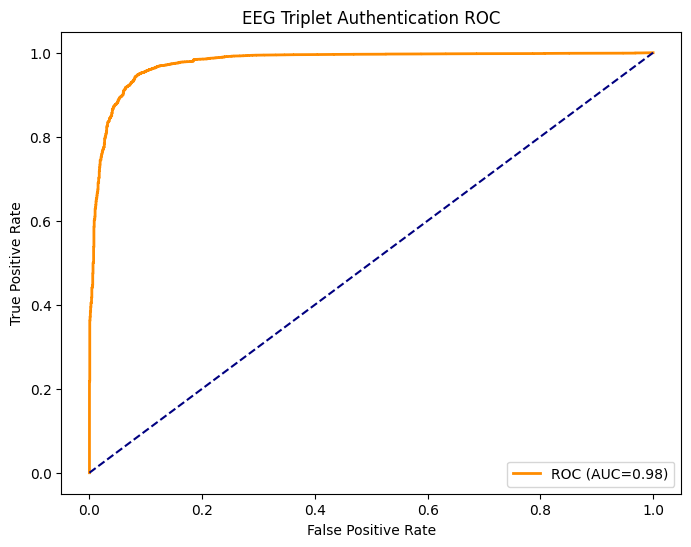

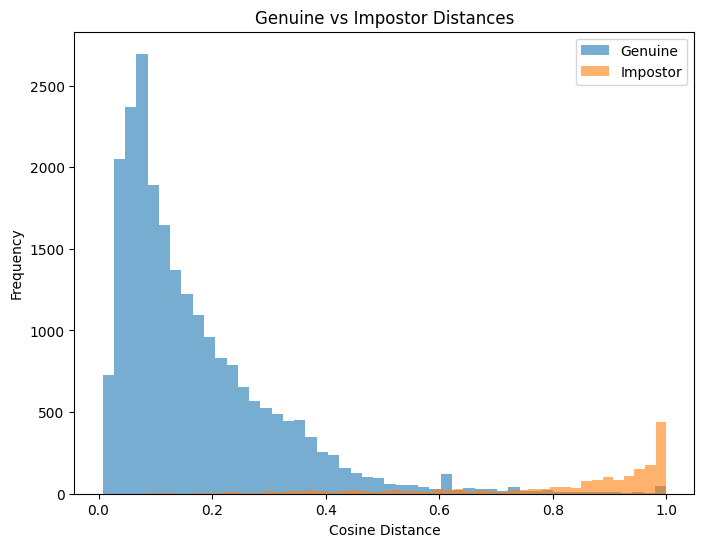

In [61]:
X_test, y_test = load_data_for_subjects(cfg.TEST_SUBJECTS, cfg)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.int32)

optimal_thresh = evaluate_authentication(fingerprint_model, X_test, y_test)

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def compute_confusion_matrix(model, X_test, y_test, threshold=0.614):
    """
    Compute and display a confusion matrix for EEG authentication.
    
    Args:
        model: fingerprint / embedding model
        X_test: test EEG segments
        y_test: corresponding labels
        threshold: similarity threshold to classify as genuine
    """
    import numpy as np
    
    # Helper: cosine similarity
    def safe_cosine(u, v, eps=1e-8):
        norm_u = np.linalg.norm(u)
        norm_v = np.linalg.norm(v)
        if norm_u < eps or norm_v < eps:
            return 0.0
        return np.dot(u, v) / (norm_u * norm_v)

    print("Generating embeddings...")
    embeddings = model.predict(X_test, batch_size=128, verbose=1)
    
    # L2 normalize
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / np.maximum(norms, 1e-8)

    y_true_list = []
    y_pred_list = []

    unique_users = np.unique(y_test)
    
    for user_idx in unique_users:
        user_indices = np.where(y_test == user_idx)[0]
        impostor_indices = np.where(y_test != user_idx)[0]
        
        if len(user_indices) < 2:
            continue
        
        split_point = len(user_indices) // 2
        enroll_indices = user_indices[:split_point]
        probe_indices = user_indices[split_point:]
        
        template = embeddings[enroll_indices].mean(axis=0)
        
        # Genuine samples
        for vec in embeddings[probe_indices]:
            sim = safe_cosine(template, vec)
            y_true_list.append(1)
            y_pred_list.append(1 if sim >= threshold else 0)
        
        # Impostor samples (sample 100)
        np.random.shuffle(impostor_indices)
        sel_imp_indices = impostor_indices[:100]
        for vec in embeddings[sel_imp_indices]:
            sim = safe_cosine(template, vec)
            y_true_list.append(0)
            y_pred_list.append(1 if sim >= threshold else 0)

    # Compute confusion matrix
    cm = confusion_matrix(y_true_list, y_pred_list, labels=[1,0])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Genuine", "Impostor"])
    
    disp.plot(cmap="Blues")
    return cm

Generating embeddings...
357/357 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
[[21144  1675]
 [  152  1748]]


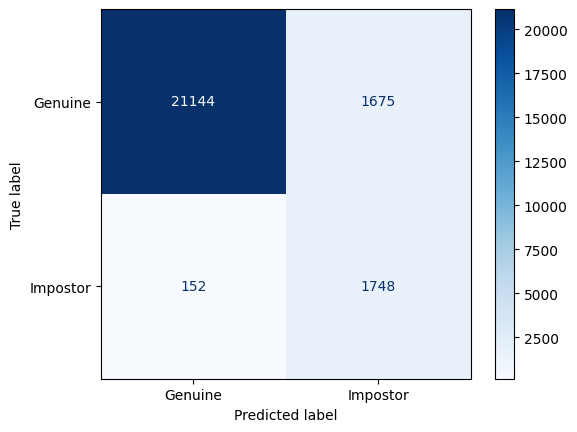

In [63]:
cm = compute_confusion_matrix(fingerprint_model, X_test, y_test, threshold=0.614)
print(cm)